### IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Creating a Dataframe

In [2]:
df =sns.load_dataset('iris')
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### DATAFRAME INFORMATION

Basic Dataframe information

In [3]:
print("\nDataframe Basic Information:\n")
df.info()
print(f'Dataframe Shape: {df.shape}')


Dataframe Basic Information:

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB
Dataframe Shape: (150, 5)


Dataframe statistical info

In [4]:
print("\nDataframe Statistical Information:")
df.describe()


Dataframe Statistical Information:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Checking for null values

In [5]:
print("\nNull Values in each column:\n")
df.isnull().sum()


Null Values in each column:



sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Statistical analysis

In [6]:
mean_median = df.groupby('species').agg(['mean', 'median'])
print(f'\n Mean and Median values by species:')
mean_median


 Mean and Median values by species:


sepal_length        sepal_width        petal_length         \
                   mean median        mean median         mean median   
species                                                                 
setosa            5.006    5.0       3.428    3.4        1.462   1.50   
versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
virginica         6.588    6.5       2.974    3.0        5.552   5.55   

           petal_width         
                  mean median  
species                        
setosa           0.246    0.2  
versicolor       1.326    1.3  
virginica        2.026    2.0

## DATA VISUALIZATION

Species count

Species counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_3232\3297116142.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species',palette='Set2')


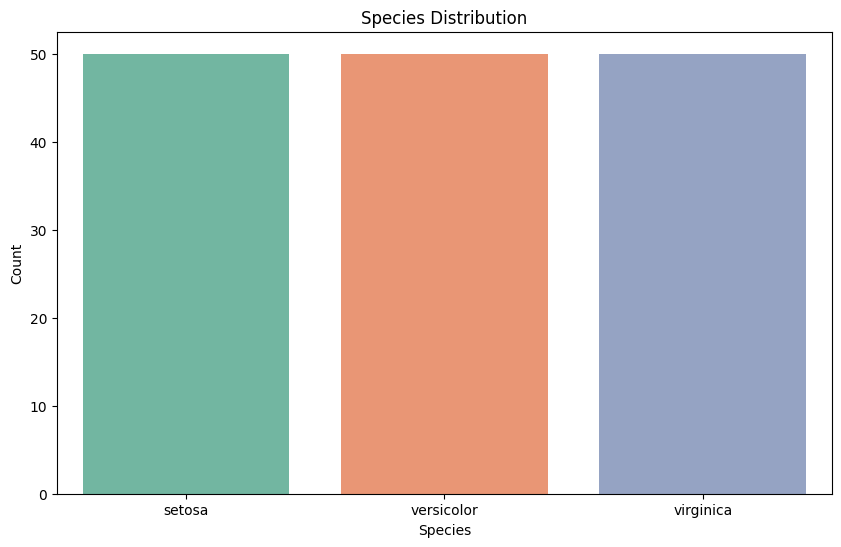

In [7]:
species_counts = df['species'].value_counts()
print(f'Species counts:\n{species_counts}')

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='species',palette='Set2')
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Species Distribution')
plt.show()


Sepal length vs Sepal width


 Average Sepal Length and Width by Species:
            sepal_length sepal_width
                   mean        mean
species                            
setosa            5.006       3.428
versicolor        5.936       2.770
virginica         6.588       2.974


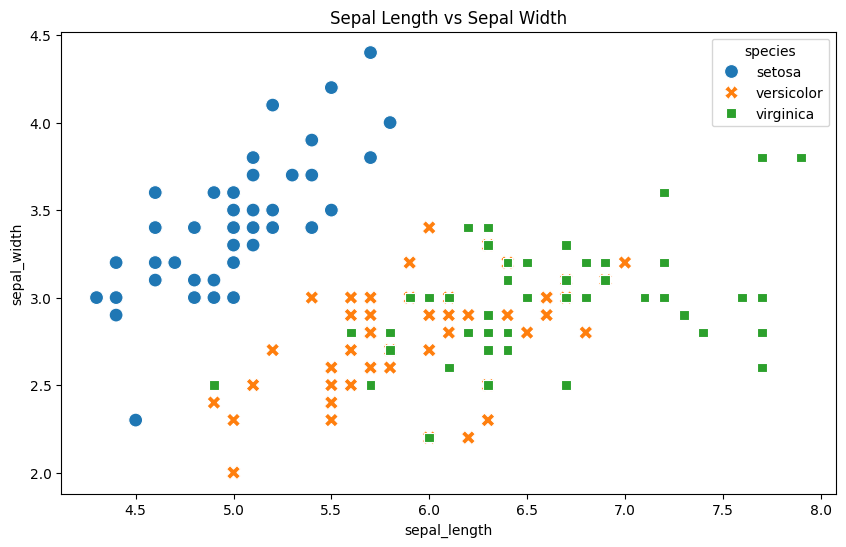

In [8]:
sepal_group = df.groupby('species')[['sepal_length', 'sepal_width']].agg(['mean'])
print(f'\n Average Sepal Length and Width by Species:\n {sepal_group}')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', style='species', s=100)
plt.title('Sepal Length vs Sepal Width')
plt.show()


Petal length vs petal width

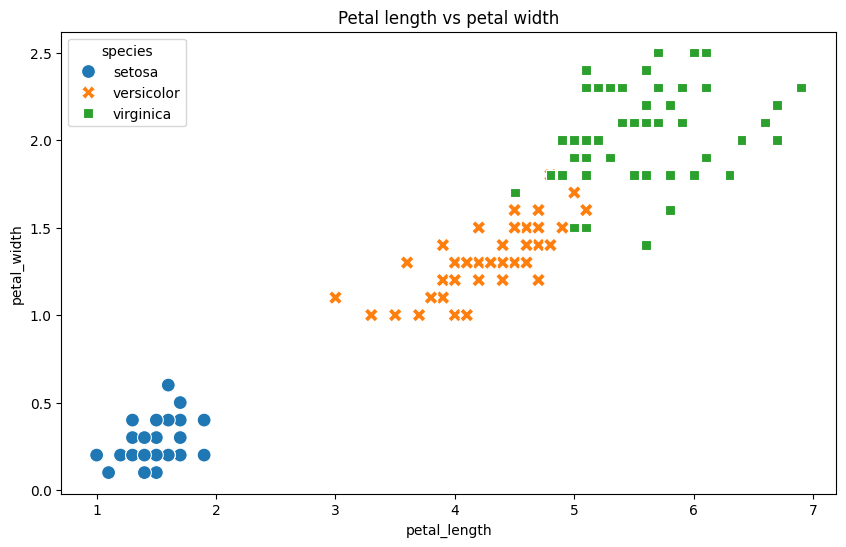

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', style='species', s=100)
plt.title('Petal length vs petal width')
plt.show()

Box plot

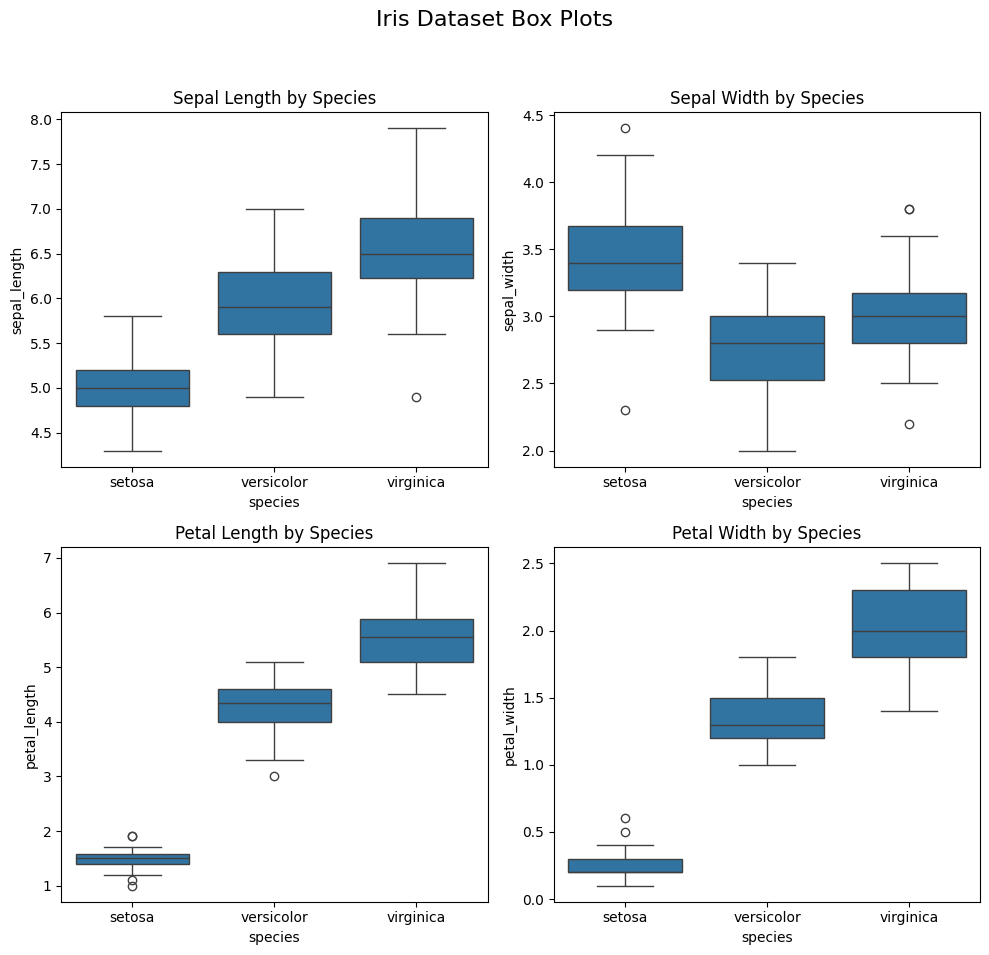

In [10]:

fig,axes = plt.subplots(2,2,figsize=(10,10))
fig.suptitle('Iris Dataset Box Plots', fontsize=16)
sns.boxplot(data=df, x='species', y='sepal_length', ax=axes[0,0])
axes[0,0].set_title('Sepal Length by Species')
sns.boxplot(data=df, x='species', y='sepal_width', ax=axes[0,1])
axes[0,1].set_title('Sepal Width by Species')
sns.boxplot(data=df, x='species', y='petal_length', ax=axes[1,0])
axes[1,0].set_title('Petal Length by Species')
sns.boxplot(data=df, x='species', y='petal_width', ax=axes[1,1])
axes[1,1].set_title('Petal Width by Species')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## MACHINE LEARNING MODEL

Model Accuracy: 100.00%

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


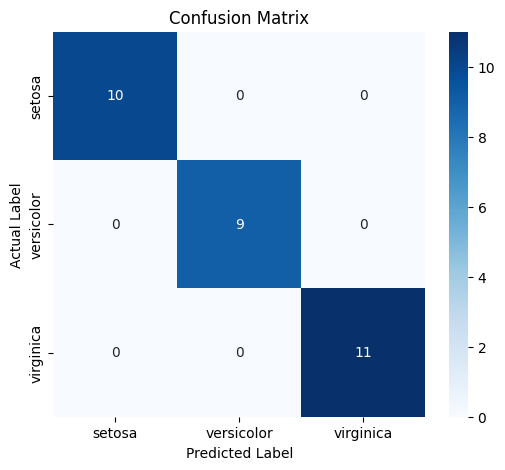

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Features and Target
X = df.drop('species', axis=1)
y = df['species']

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Building Logistic Regression Model
model = LogisticRegression(max_iter=200)

# Training the model
model.fit(X_train_scaled, y_train)

# Making Predictions
y_pred = model.predict(X_test_scaled)

# Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# CONFUSION MATRIX VISUALIZATION

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

Species prediction

In [12]:
# Sample flower measurements
sample_data = pd.DataFrame({
    'sepal_length': [5.1],
    'sepal_width': [3.5],
    'petal_length': [1.4],
    'petal_width': [0.2]
})

# Scale the sample data
sample_scaled = scaler.transform(sample_data)

# Predict species
prediction = model.predict(sample_scaled)
print("Predicted Species:", prediction[0])

Predicted Species: setosa
